# USING PCA TO FIND AN OPTIMISED RANDOM FOREST CLASSIFIER

# EDA

At the beginning I want to note that in this project I will aim to not do graphs or procedures that won't be useful towards my final goal which is checking if PCA will help with optimising my Random Forest model and if so with how many components, and then optimising the final RF model. When I implemented something in the project I was thinking if it will actually bring some value in. My aim is clarity and usefulness. Let's begin the exploration.

Some imports:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
import sys
import os
warnings.resetwarnings()
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

I surpressed warnings as I was getting some future warnings for some cells.

Let's import the dataset and take a look at it.

In [2]:
df = pd.read_csv("data.csv")
df.head()

,Unnamed: 0,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,0,2,0.450345,0.002284,-7.386961,1.608574,-0.065830,1.552955,0.623425,3.146079,...,4.454433,1.816417,1.464800,0.584120,14.477832,3.425533,-0.054999,0.379366,1.234348,-0.806352
1,1,4,-1.344353,-0.001163,3.892313,0.191210,-0.236562,-0.539929,1.057222,-1.306748,...,-1.230220,-0.874997,-0.960071,-0.055769,6.122070,0.087470,0.107181,-2.085442,0.226830,-0.467282
2,2,2,-0.161815,-0.002377,-3.884722,1.991981,0.565774,-0.413597,2.036506,1.345159,...,-0.309083,0.392057,1.480934,-0.435065,16.041942,3.296739,1.141086,-0.771039,0.045097,-2.003585
3,3,4,-0.613100,0.008052,-11.429119,-0.195807,0.589675,-0.268313,2.029290,-4.123495,...,3.940179,-2.279353,0.431355,0.123803,-10.174401,2.573194,0.066964,-2.478729,-1.339569,-0.960142
4,4,4,-1.814345,0.004193,-2.340890,0.141347,-0.311410,0.228829,1.055476,-1.018601,...,-4.481931,0.916158,0.452793,0.479734,-0.417844,-0.452521,0.506627,1.110166,0.124187,0.395767


Let's check the shape and features type.

In [3]:
print("shape", df.shape)
print("type:", df.dtypes)

shape (1100, 32)
type: Unnamed: 0      int64
label           int64
feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
feature_22    float64
feature_23    float64
feature_24    float64
feature_25    float64
feature_26    float64
feature_27    float64
feature_28    float64
feature_29    float64
feature_30    float64
dtype: object


We can see that all of the 30 features are numerical and more precisely floats apart from the target variable "label" which consists of integers. Our dataset consists of 1100 samples and 30 features plus the label feature. Let's check if there are any null variables.

In [4]:
print(df.isnull().any().any())

False


We don't have any null variables which is good. Let's check the number of samples with each label.

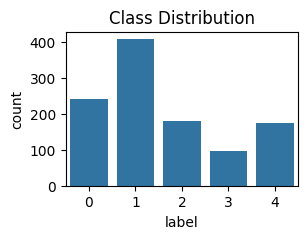

In [5]:
plt.figure(figsize=(3, 2))
sns.countplot(x=df.iloc[:, 1])
plt.title("Class Distribution")
plt.show()

We can see a significant label disproportion. The dataset consists of significantly more samples of label 1 type than others. Samples of labels 0, 2 and 4 are more or less of equal number. Samples of label 3 are the smallest in number counting only around 100 samples. This disproportion is very significant and we will definitely need to bare it in mind during our model selection. Let's plot some example features's distributions.

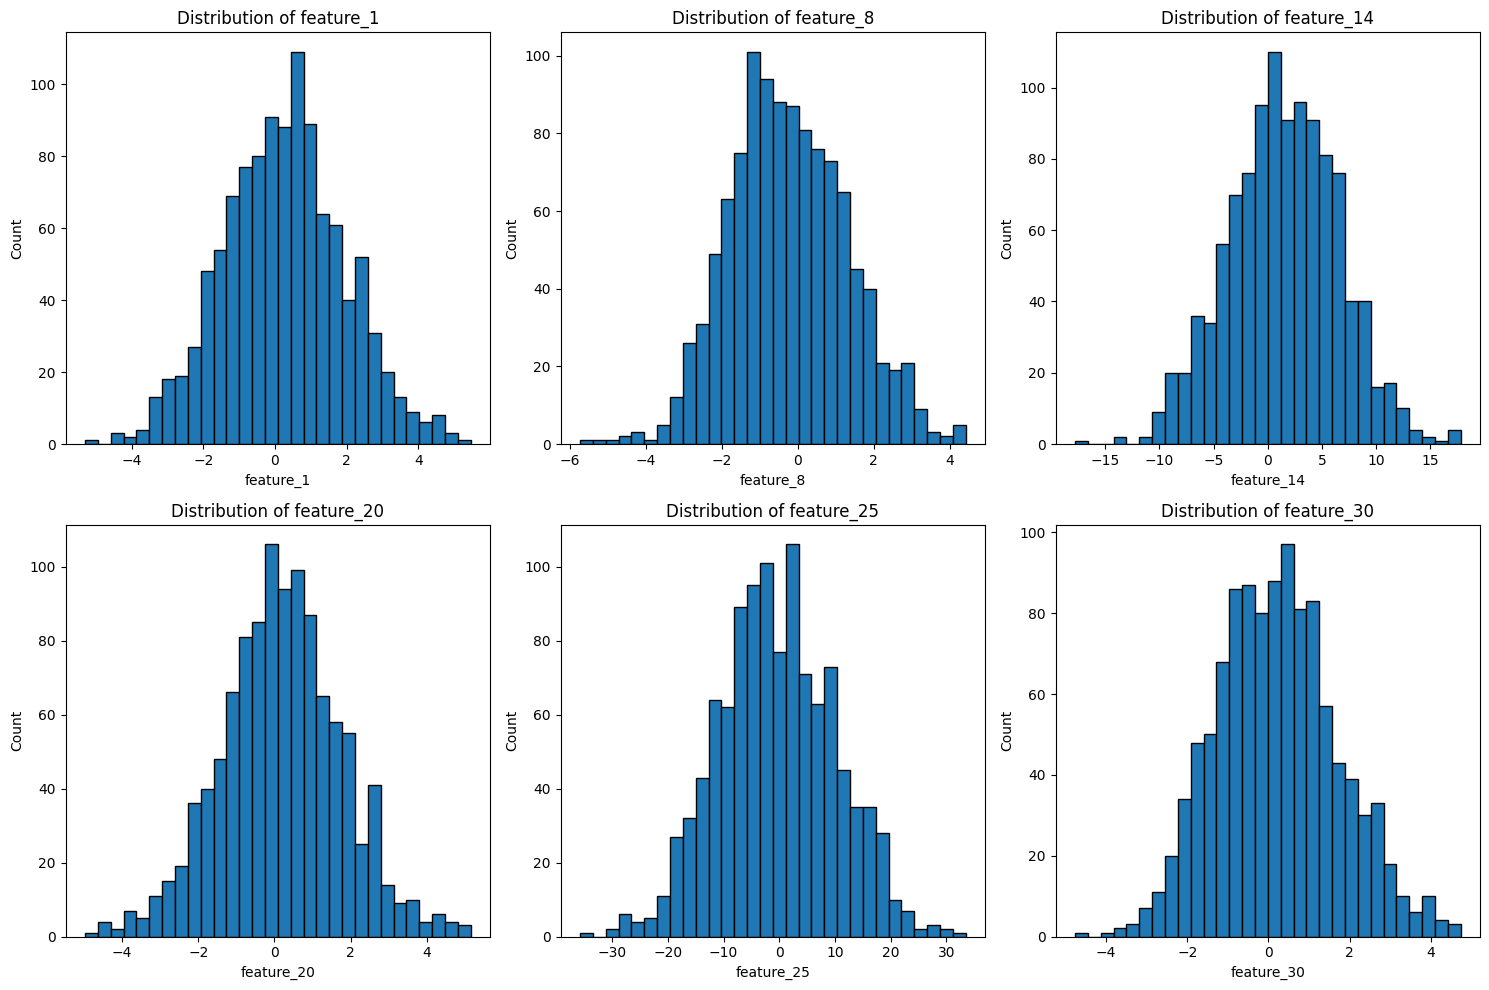

In [6]:
features = ['feature_1', 'feature_8', 'feature_14', 'feature_20', 'feature_25', 'feature_30']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[feature], bins=30, edgecolor='black')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

We can clearly see that distribution of features is more or less centered at 0 and symmetrical. Of course the distributions of each features are unique and differ, but we can see a general pattern for the features that resemble a normal distribution centered at 0.

# PCA

In order to perform PCA on our dataset, let's first name our X (features) and y (target). To do that let's see how our columns are named.

In [7]:
print(df.columns)

Index(['Unnamed: 0', 'label', 'feature_1', 'feature_2', 'feature_3',
       'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8',
       'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13',
       'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18',
       'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28',
       'feature_29', 'feature_30'],
      dtype='object')


In [8]:
X = df.drop(['Unnamed: 0', 'label'], axis=1)
y = df['label']

Let's check how our range, mean and variance looks for different features.

In [9]:
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Unnamed: 0,549.500000,317.686953,0.000000,1099.000000
label,1.598182,1.345770,0.000000,4.000000
feature_1,0.246446,1.687234,-5.302853,5.461541
feature_2,0.000512,0.003942,-0.014432,0.013911
feature_3,-1.279936,3.987397,-15.267712,11.756635
feature_4,0.133947,1.175048,-3.599914,3.996718
feature_5,0.074370,0.525586,-1.678512,1.620558
feature_6,0.061587,0.690248,-2.469815,2.312180
feature_7,0.092738,1.116000,-3.532135,3.480730
feature_8,-0.245393,1.545152,-5.727775,4.416494


The variance and range is different for different features and for some it differs significantly, so we will perform standarization.

### Scaled PCA

Let's get an initial idea about how PCA will influence our dataset by doing the scaled version of PCA first, so first scaling our whole dataset and then performing PCA on the whole set and check it's effectiveness vs cumulative variance on different numbers of components.

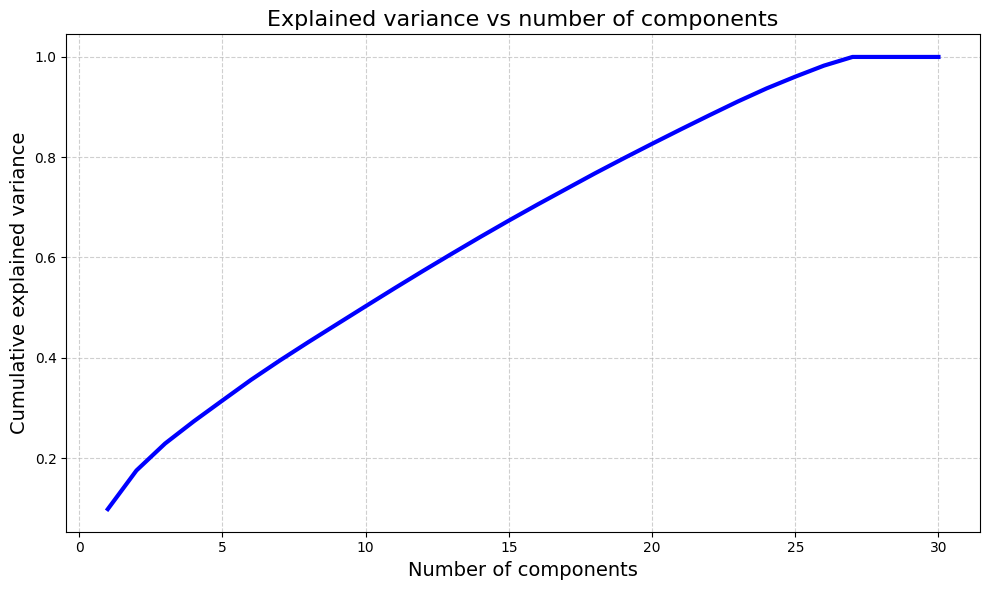

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA().fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
dimensions = np.arange(1, len(cumsum) + 1)

plt.figure(figsize=(10, 6))
plt.plot(dimensions, cumsum, linewidth=3, color="blue")
plt.xlabel("Number of components", fontsize=14)
plt.ylabel("Cumulative explained variance", fontsize=14)
plt.title("Explained variance vs number of components", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

We don't see a clear elbow on the plot. However, as our only model we will focus on is random forest, I though about chosing the number of components directly based on the RF accuracy results and F1 score. Let's use pipeline to make sure we will avoid data leakage and 5-fold cross validation to make sure our results are consistent and precise.

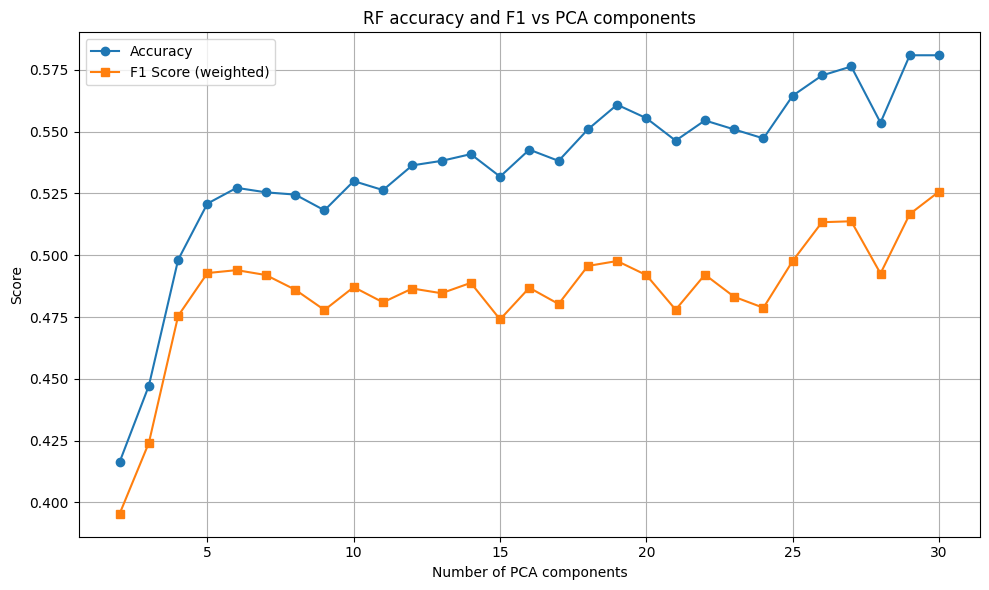

In [11]:
pipe = Pipeline([
    ('pca', PCA(random_state=42)),
    ('rf',  RandomForestClassifier(random_state=42))
])

component_range = range(2, 31)
accuracies, f1_scores = [], []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in component_range:
    pipe.set_params(pca__n_components=n)
    accuracies.append(cross_val_score(pipe, X_scaled, y,
                                      cv=cv, scoring='accuracy',
                                      n_jobs=-1).mean())
    f1_scores.append(cross_val_score(pipe, X_scaled, y,
                                     cv=cv, scoring='f1_weighted',
                                     n_jobs=-1).mean())
plt.figure(figsize=(10, 6))
plt.plot(component_range, accuracies, marker='o', label='Accuracy')
plt.plot(component_range, f1_scores, marker='s', label='F1 Score (weighted)')
plt.xlabel('Number of PCA components')
plt.ylabel('Score')
plt.title('RF accuracy and F1 vs PCA components')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

We can clearly see that the F1 score and accuracy scores are not the best for any number of components retained, so let's try the non-scaled PCA to check if that one won't perform better, and only then pick our final number of components and type of PCA.

### Non-scaled PCA

Let's first get the general idea as for the scaled PCA on the whole dataset and graph the cumulative variance vs number of components.

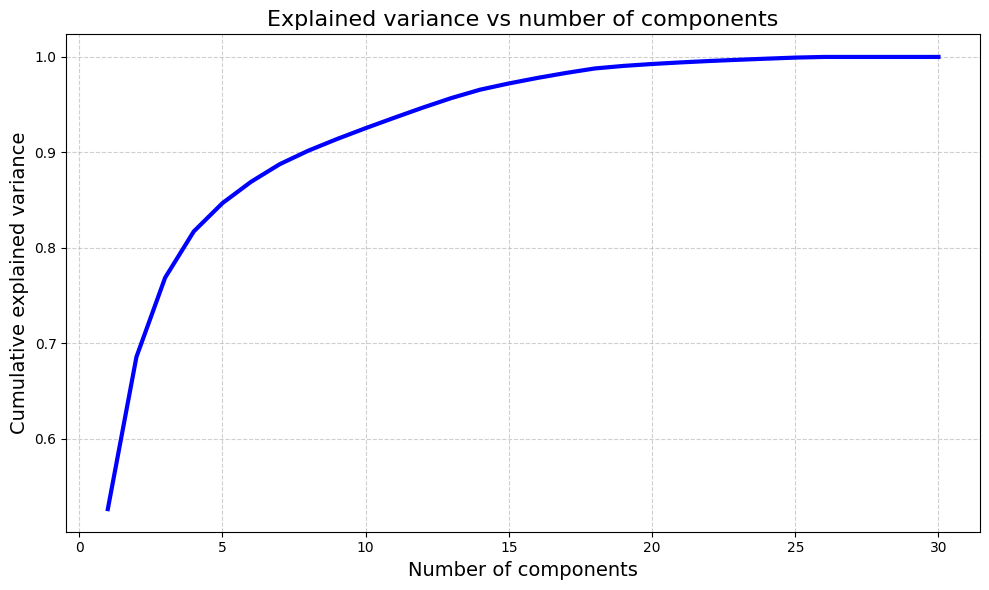

In [12]:
pca_full = PCA().fit(X)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
dimensions = np.arange(1, len(cumsum) + 1)

plt.figure(figsize=(10, 6))
plt.plot(dimensions, cumsum, linewidth=3, color="blue")
plt.xlabel("Number of components", fontsize=14)
plt.ylabel("Cumulative explained variance", fontsize=14)
plt.title("Explained variance vs number of components", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

There is a long elbow visible on the graph, and we can see that the part of the curve that resembles an elbow the most is around 85-95% of variance explained. However, to make final judgments let's again check the Random Forest model's accuracy on each number of non-scaled PCA components.

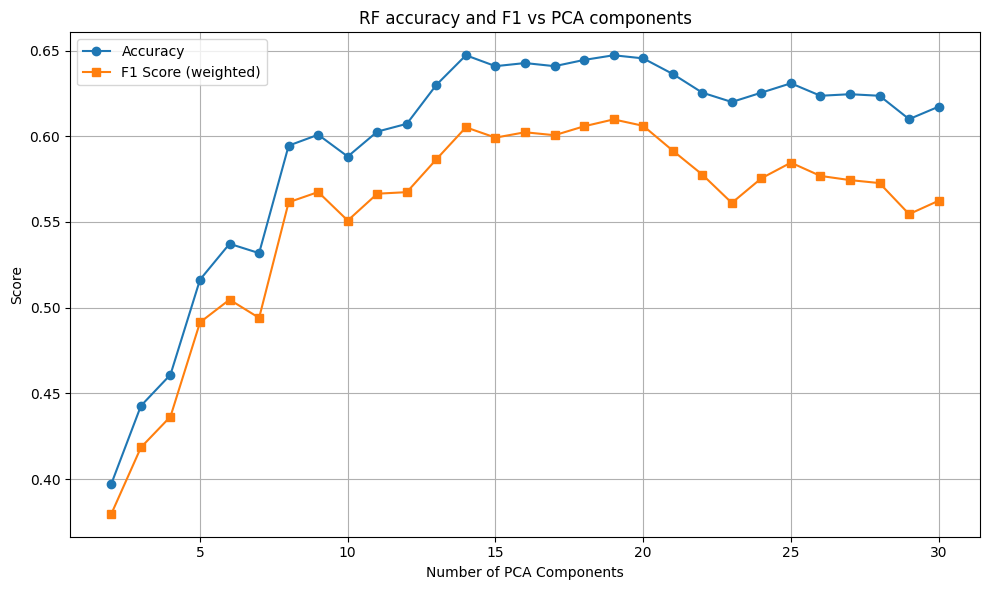

In [13]:
pipe = Pipeline([
    ('pca', PCA(random_state=42)),
    ('rf',  RandomForestClassifier(random_state=42))
])

component_range = range(2, 31)
accuracies, f1_scores = [], []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in component_range:
    pipe.set_params(pca__n_components=n)
    accuracies.append(
        cross_val_score(pipe, X, y,
                        cv=cv, scoring='accuracy',
                        n_jobs=-1).mean()
    )
    f1_scores.append(
        cross_val_score(pipe, X, y,
                        cv=cv, scoring='f1_weighted',
                        n_jobs=-1).mean()
    )

plt.figure(figsize=(10, 6))
plt.plot(component_range, accuracies, marker='o', label='Accuracy')
plt.plot(component_range, f1_scores, marker='s', label='F1 Score (weighted)')
plt.xlabel('Number of PCA Components')
plt.ylabel('Score')
plt.title('RF accuracy and F1 vs PCA components')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

We can clearly see that keeping 14 and 19 components achieves highest scores. Additionaly we can already spot a way higher result for non scaled PCA - about 7% incease in accuracy and even more when it comes to F1 weighted score compared to the scaled PCA. The difference is so big that we will just proceed to use the non scaled PCA from now on to train the model. Let's save our best non-scaled PCA split below and keep 14 components to have less components.

In [14]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
pca = PCA(n_components=14, random_state=42)
X_train_reduced = pca.fit_transform(X_train_raw)
X_test_reduced  = pca.transform(X_test_raw)

print(f"Original shape: {X.shape}")
print(f"Train-reduced shape: {X_train_reduced.shape}")
print(f"Test-reduced  shape: {X_test_reduced.shape}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Number of components retained: {pca.n_components_}")

Original shape: (1100, 30)
Train-reduced shape: (880, 14)
Test-reduced  shape: (220, 14)
Total explained variance: 0.9657
Number of components retained: 14


We kept 14 components and retained 96.57% of the variance explained. Let's proceed to train the model.

# Random forest

Let's train our first RF model using our non-scaled data and see the results.

In [15]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_reduced, y_train)

y_pred = rf.predict(X_test_reduced)
print("Base RF using non-scaled PCA")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Base RF using non-scaled PCA
Accuracy: 0.6727272727272727
              precision    recall  f1-score   support

           0       0.61      0.71      0.65        48
           1       0.68      0.99      0.81        81
           2       0.62      0.42      0.50        36
           3       0.67      0.20      0.31        20
           4       0.88      0.43      0.58        35

    accuracy                           0.67       220
   macro avg       0.69      0.55      0.57       220
weighted avg       0.69      0.67      0.64       220



We got 67.27% accuracy score, but we can see some imbalance between scores on different classes like f1-score differs by for example nearly 50% between 1st class and 3rd class. This clearly happens because our data has different number of samples for each class. For the 1st class we have around 400 samples while for the 3rd one around 100. Let's try to adress this issue and put a big emphasis on it as balance is key for good predictions on new datasets. Let's plot and store normalized confusion matrix for our first base model to compare our final tuned model at the end to see the improvement.

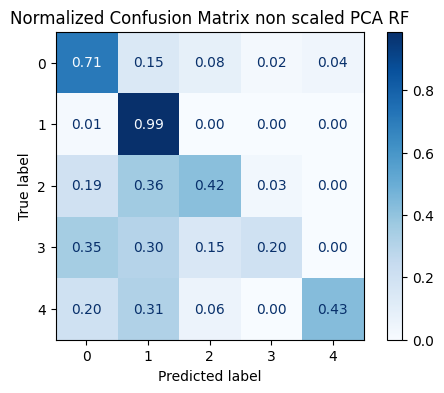

In [16]:
cm = confusion_matrix(y_test, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(cm)
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix non scaled PCA RF")
plt.show()

This imbalance is clearly visible on the confusion matrix. With class 1 being predicted 99% of the times correctly, while class 3 for example only 20% times!

Let's check how the RF will perform on the original data.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Original data model:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Original data model:
Accuracy: 0.6409090909090909

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.69      0.63        48
           1       0.66      0.94      0.77        81
           2       0.59      0.44      0.51        36
           3       1.00      0.30      0.46        20
           4       0.67      0.29      0.40        35

    accuracy                           0.64       220
   macro avg       0.70      0.53      0.56       220
weighted avg       0.66      0.64      0.61       220



The accuracy score is lower by more than 3% plus there is even higher disproportion between different classes' scores. Let's stick with the non-scaled PCA model for further research and not use the original data for exploration anymore as it turned out to be way worse for our RF classifier.

CONCLUSION OF THINGS ACHIEVED BY NOW:  
-We realised that PCA with non-scaled dataset achieves the best scores.   
-We achieved initial accuracy scores for our RF model around 67.2%.    
-We realized there's a big performance difference between different classes for our RF model.

# Getting rid of the problem of imbalance between classes

### Different imbalance solutions

First let's try implementing the parameter class_weight = balanced to our RF model and see if we will get more balanced results.

In [18]:
rf_bal = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_bal.fit(X_train_reduced, y_train)

y_pred = rf_bal.predict(X_test_reduced)
print("Class-weighted RF")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Class-weighted RF
Accuracy: 0.6818181818181818
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        48
           1       0.66      0.99      0.79        81
           2       0.75      0.50      0.60        36
           3       0.67      0.30      0.41        20
           4       0.83      0.43      0.57        35

    accuracy                           0.68       220
   macro avg       0.71      0.57      0.60       220
weighted avg       0.70      0.68      0.66       220



Our accuracy score increased by 1% and F1 weighted and macro average scores increased significantly too. We can see a solid improvement, but let's check other oversampling methods too. First let's see RandomOverSampler:

In [19]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_reduced, y_train)

rf_ros = RandomForestClassifier(random_state=42)
rf_ros.fit(X_train_ros, y_train_ros)

y_pred = rf_ros.predict(X_test_reduced)
print("RandomOverSampler RF")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

RandomOverSampler RF
Accuracy: 0.7045454545454546
              precision    recall  f1-score   support

           0       0.66      0.77      0.71        48
           1       0.74      0.96      0.83        81
           2       0.70      0.53      0.60        36
           3       0.57      0.40      0.47        20
           4       0.76      0.37      0.50        35

    accuracy                           0.70       220
   macro avg       0.69      0.61      0.62       220
weighted avg       0.70      0.70      0.68       220



We can see even higher accuracy improvement, by more than 3% and even higher macro and weighted average F1 scores. Lastly let's check SMOTE oversampling method.

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smt, y_train_smt = smote.fit_resample(X_train_reduced, y_train)

rf_smt = RandomForestClassifier(random_state=42)
rf_smt.fit(X_train_smt, y_train_smt)

y_pred = rf_smt.predict(X_test_reduced)
print("SMOTE RF")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SMOTE RF
Accuracy: 0.6909090909090909
              precision    recall  f1-score   support

           0       0.68      0.71      0.69        48
           1       0.76      0.84      0.80        81
           2       0.57      0.58      0.58        36
           3       0.45      0.45      0.45        20
           4       0.83      0.57      0.68        35

    accuracy                           0.69       220
   macro avg       0.66      0.63      0.64       220
weighted avg       0.70      0.69      0.69       220



The accuracy and F1 scores increased compared to the base model. However, compared to the RandomOverSampler, we got a slight drop in accuracy score, but on the other hand an increase in F1 scores. The results are very close, but let's not forget that we just used a single split for those results. Let's do a comprehensive comparison of all models obtained by now and see which one will perform the best after implementing 5-fold cross validation.

### Final comparison

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scorer = make_scorer(accuracy_score)
f1_scorer  = make_scorer(f1_score, average="weighted")
base_rf = RandomForestClassifier(random_state=42)

models = {
    "Base (PCA14)": Pipeline([
        ("pca", PCA(n_components=14, random_state=42)),
        ("clf", base_rf)
    ]),
    "SMOTE": Pipeline([
        ("pca",  PCA(n_components=14, random_state=42)),
        ("smote", SMOTE(random_state=42)),
        ("clf",   base_rf)
    ]),
    "RandomOverSampler": Pipeline([
        ("pca",  PCA(n_components=14, random_state=42)),
        ("ros",  RandomOverSampler(random_state=42)),
        ("clf",  base_rf)
    ]),
    "ClassWeightBalanced": Pipeline([
        ("pca", PCA(n_components=14, random_state=42)),
        ("clf", RandomForestClassifier(class_weight="balanced",
                                       random_state=42))
    ])
}

acc_results = {name: cross_val_score(m, X, y, cv=cv,
                                     scoring=acc_scorer, n_jobs=-1)
               for name, m in models.items()}
f1_results  = {name: cross_val_score(m, X, y, cv=cv,
                                     scoring=f1_scorer, n_jobs=-1)
               for name, m in models.items()}

print("\nCross-validation accuracy per fold:")
print(pd.DataFrame(acc_results))
print("\nCross-validation F1 score per fold:")
print(pd.DataFrame(f1_results))
print("\nAverage accuracy:")
print(pd.Series({k: v.mean() for k, v in acc_results.items()}))
print("\nAverage F1 score:")
print(pd.Series({k: v.mean() for k, v in f1_results.items()}))


Cross-validation accuracy per fold:
   Base (PCA14)     SMOTE  RandomOverSampler  ClassWeightBalanced
0      0.645455  0.677273           0.695455             0.640909
1      0.631818  0.627273           0.636364             0.645455
2      0.650000  0.645455           0.663636             0.659091
3      0.650000  0.640909           0.645455             0.627273
4      0.659091  0.663636           0.668182             0.636364

Cross-validation F1 score per fold:
   Base (PCA14)     SMOTE  RandomOverSampler  ClassWeightBalanced
0      0.616414  0.670964           0.682777             0.610685
1      0.590720  0.617849           0.609641             0.603566
2      0.598150  0.634386           0.637195             0.612767
3      0.613581  0.636903           0.622329             0.591577
4      0.607274  0.655031           0.640934             0.596808

Average accuracy:
Base (PCA14)           0.647273
SMOTE                  0.650909
RandomOverSampler      0.661818
ClassWeightBalanced

Based on all results we got by now, we should clearly consider picking either SMOTE or RandomOverSampler model. ROS got a better result on a single split before on accuracy, but lower on F1 scores. In cross validation section, SMOTE again performed better with F1 score, but again worse with accuracy. However, the results of F1 score between different splits are much more consistent for SMOTE. With our dataset being very imbalanced we need to put a strong emphasis on F1 score and consistent results. From those reasons I decided to pick SMOTE eventhough it is a more complex model. Consistency across cross validation and solid F1 score results made me see more value in chosing it. We will conduct tuning up the model with our new SMOTE model. Handling imbalance is crucial for facing different testing datasets in future for our model.

# Tuning up the model

We will use search methods and graphs to tune up our model and test which parameters will turn out to be the best ones for our use. First, let's plot couple of graphs showing the different most important parameters' values vs accuracy and F1 scores to get a general idea of what bounds should we aim to set for parameters' values.    
   
Let's save our SMOTE model first, for clarity:

In [22]:
smote = SMOTE(random_state=42)
X_train_smt, y_train_smt = smote.fit_resample(X_train_reduced, y_train)

rf_smt = RandomForestClassifier(random_state=42)
rf_smt.fit(X_train_smt, y_train_smt)

y_pred = rf_smt.predict(X_test_reduced)
print("SMOTE RF")
print("Accuracy:", accuracy_score(y_test, y_pred))

SMOTE RF
Accuracy: 0.6909090909090909


Let's start with the analysis and begin with the number of trees parameter.

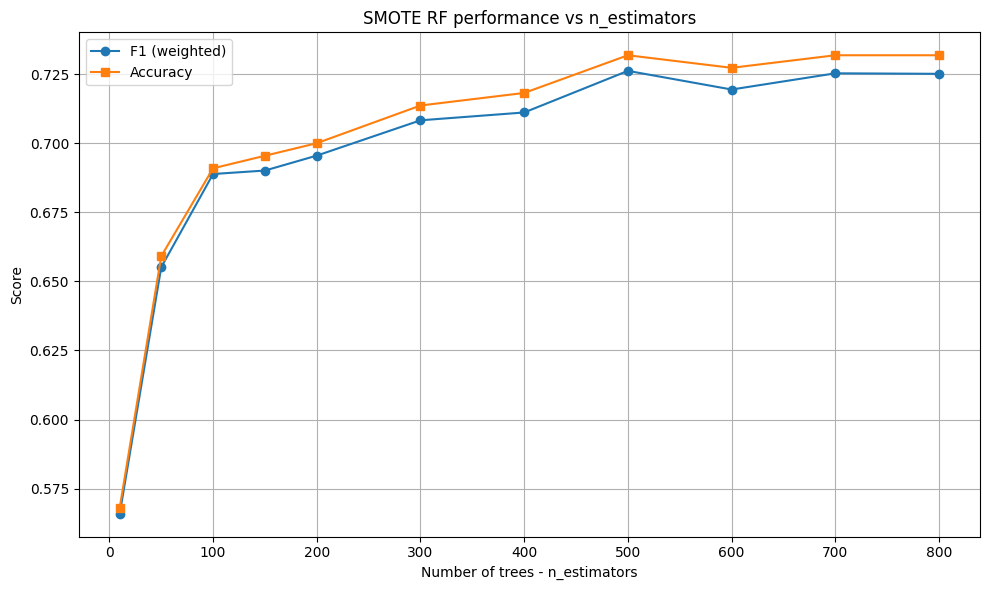

In [23]:
estimator_range   = [10, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800]
f1_scores         = []
accuracy_scores   = []

for n in estimator_range:
    rf = RandomForestClassifier(
            n_estimators=n,
            random_state=42)
    rf.fit(X_train_smt, y_train_smt)
    y_pred = rf.predict(X_test_reduced)
    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(estimator_range, f1_scores,  marker='o', label='F1 (weighted)')
plt.plot(estimator_range, accuracy_scores, marker='s', label='Accuracy')
plt.xlabel("Number of trees - n_estimators")
plt.ylabel("Score")
plt.title("SMOTE RF performance vs n_estimators")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

The best performance was obtained with 500 or more trees.

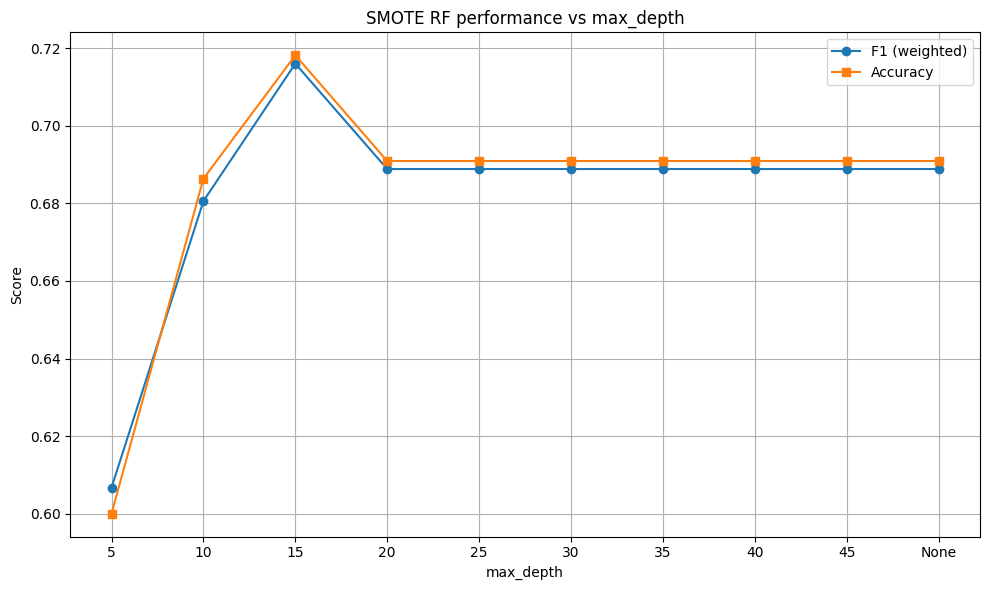

In [24]:
depth_range       = [5, 10, 15, 20, 25, 30, 35, 40, 45, None]
f1_scores         = []
accuracy_scores   = []

for depth in depth_range:
    rf = RandomForestClassifier(
            max_depth=depth,
            random_state=42)
    rf.fit(X_train_smt, y_train_smt)
    y_pred = rf.predict(X_test_reduced)
    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

labels = [str(d) for d in depth_range]
plt.figure(figsize=(10, 6))
plt.plot(labels, f1_scores,  marker='o', label='F1 (weighted)')
plt.plot(labels, accuracy_scores, marker='s', label='Accuracy')
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.title("SMOTE RF performance vs max_depth")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

The performance is the best with value 15, but we can see consistency between values 10 and 20 or more.

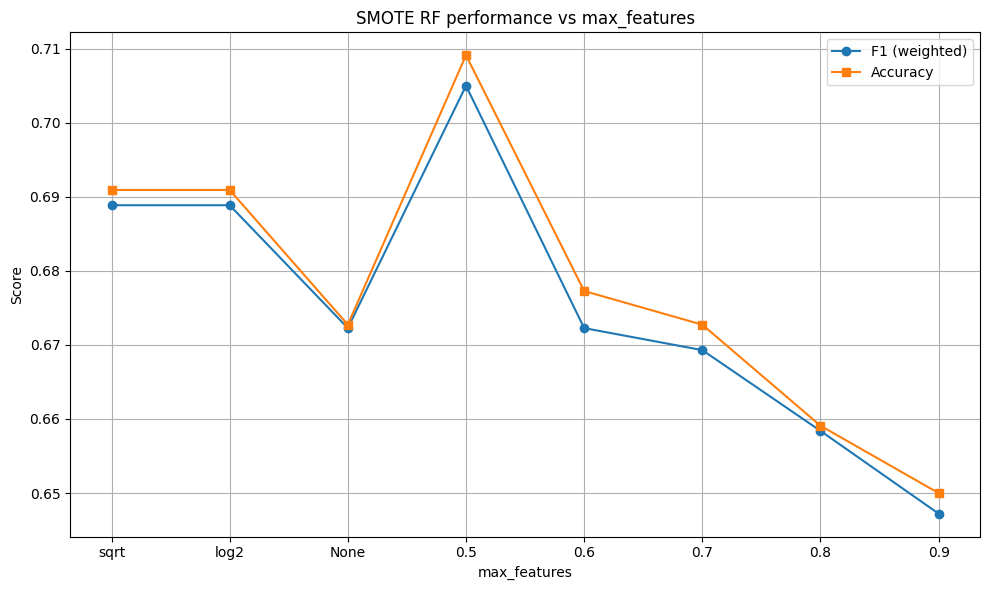

In [25]:
features_options  = ['sqrt', 'log2', None, 0.5, 0.6, 0.7, 0.8, 0.9]
f1_scores         = []
accuracy_scores   = []

for val in features_options:
    rf = RandomForestClassifier(
            max_features=val,
            random_state=42)
    rf.fit(X_train_smt, y_train_smt)
    y_pred = rf.predict(X_test_reduced)
    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

labels = [str(v) for v in features_options]
plt.figure(figsize=(10, 6))
plt.plot(labels, f1_scores,  marker='o', label='F1 (weighted)')
plt.plot(labels, accuracy_scores, marker='s', label='Accuracy')
plt.xlabel("max_features")
plt.ylabel("Score")
plt.title("SMOTE RF performance vs max_features")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

The best performance was with 0.5 value for max_features. However, sqrt and log2 are also better than the others.

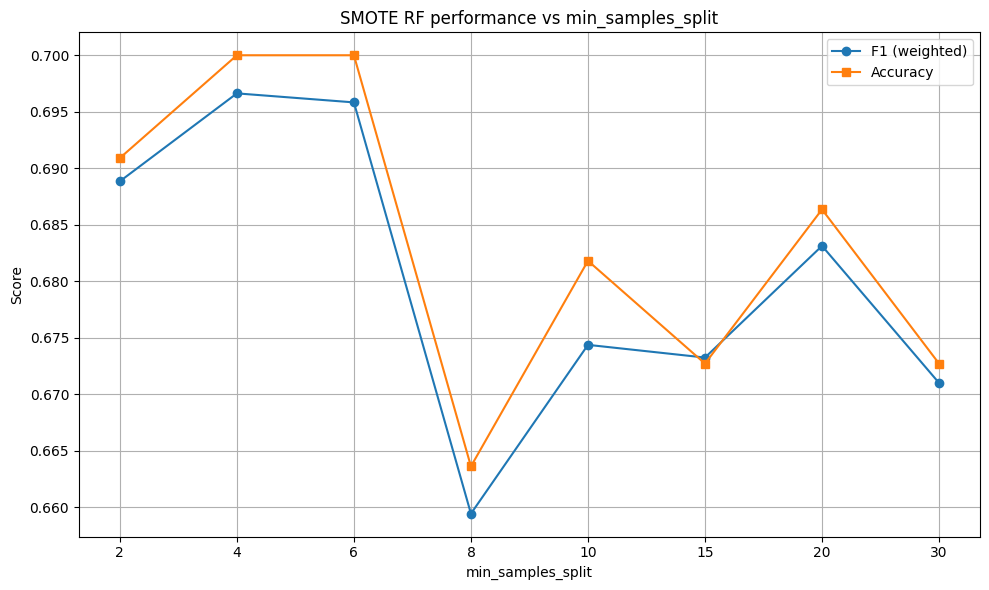

In [26]:
split_values      = [2, 4, 6, 8, 10, 15, 20, 30]
f1_scores         = []
accuracy_scores   = []

for val in split_values:
    rf = RandomForestClassifier(
            min_samples_split=val,
            random_state=42)
    rf.fit(X_train_smt, y_train_smt)
    y_pred = rf.predict(X_test_reduced)
    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

labels = [str(v) for v in split_values]
plt.figure(figsize=(10, 6))
plt.plot(labels, f1_scores,  marker='o', label='F1 (weighted)')
plt.plot(labels, accuracy_scores, marker='s', label='Accuracy')
plt.xlabel("min_samples_split")
plt.ylabel("Score")
plt.title("SMOTE RF performance vs min_samples_split")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

The best performance for min samples split was obtained with values 4, 5 and 6. Values 2 and 3 are also fine.

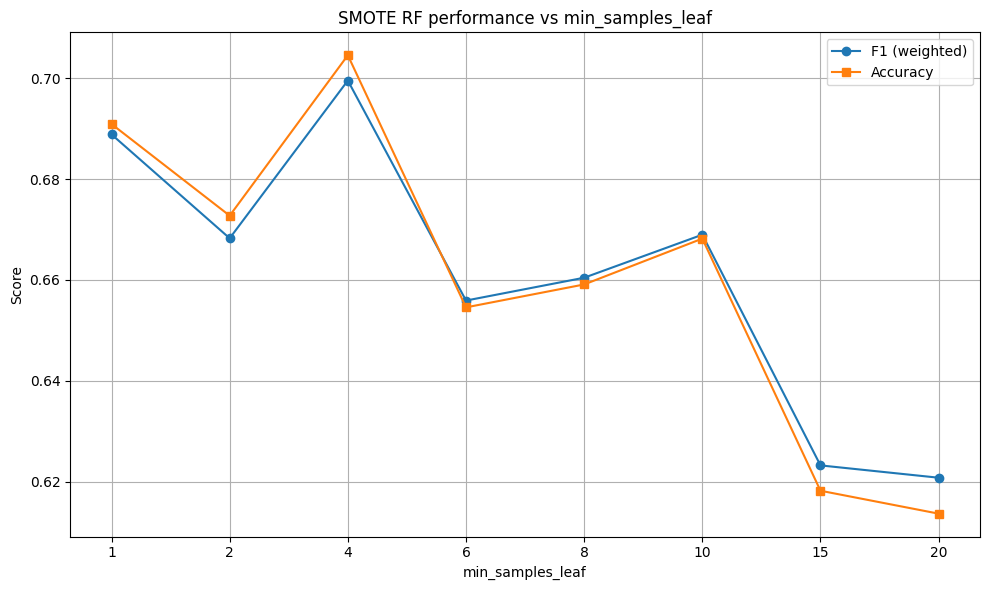

In [27]:
leaf_values       = [1, 2, 4, 6, 8, 10, 15, 20]
f1_scores         = []
accuracy_scores   = []

for val in leaf_values:
    rf = RandomForestClassifier(
            min_samples_leaf=val,
            random_state=42)
    rf.fit(X_train_smt, y_train_smt)
    y_pred = rf.predict(X_test_reduced)
    f1_scores.append(f1_score(y_test, y_pred, average="weighted"))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

labels = [str(v) for v in leaf_values]
plt.figure(figsize=(10, 6))
plt.plot(labels, f1_scores,  marker='o', label='F1 (weighted)')
plt.plot(labels, accuracy_scores, marker='s', label='Accuracy')
plt.xlabel("min_samples_leaf")
plt.ylabel("Score")
plt.title("SMOTE RF performance vs min_samples_leaf")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Best performance - 4 or 1 min samples leaf with 2 being also okay.

# Grid and Randomized search

We enter this section with a model built based on non-scaled PCA, SMOTE oversampling method, and random forest technique, achieving 69.09% accuracy score. Let's perform randomized search.

Based on the previous section those are the values for parameters we should bare in mind:

| Hyper-parameter | Best values | Other okay values|
|-----------------|---------------------------|--------------------------------|
| n_estimators | ≥ 500 | - |
| max_depth | 15 | 10, >= 20 |
| max_features | 0.5 | sqrt or log2 |
| min_samples_split | 4, 5, 6 | 2, 3 |
| min_samples_leaf | 1 or 4 | 2 |

Of course different parameters can work best together so those are not the final values we should set, but we just use it as a sort of estimation of good values for each parameter.    

Our default model before tuning:

In [28]:
smote = SMOTE(random_state=42)
X_train_smt, y_train_smt = smote.fit_resample(X_train_reduced, y_train)
rf_smt = RandomForestClassifier(random_state=42)
rf_smt.fit(X_train_smt, y_train_smt)

y_pred = rf_smt.predict(X_test_reduced)
print("SMOTE RF")
print("Accuracy:", accuracy_score(y_test, y_pred))

SMOTE RF
Accuracy: 0.6909090909090909


### Randomized search

In [29]:
from scipy.stats import randint

pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf",    RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_distrib = {
    "rf__n_estimators": randint(400,600),
    "rf__max_depth": randint(10,20),
    "rf__max_features": ["sqrt", None, 0.5],
    "rf__min_samples_split": [4,5,6],
    "rf__min_samples_leaf": [ 2, 4,6]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rnd_search = RandomizedSearchCV(
    estimator      = pipe,
    param_distributions = param_distrib,
    n_iter         = 30,
    scoring        = "f1_weighted",
    cv             = cv,
    n_jobs         = -1,
    random_state   = 42,
    verbose        = 1
)

rnd_search.fit(X_train_reduced, y_train)
print("Best parameters:", rnd_search.best_params_)
best_rnd = rnd_search.best_estimator_
y_pred   = best_rnd.predict(X_test_reduced)
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'rf__max_depth': 16, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 550}
Accuracy : 0.7136363636363636
              precision    recall  f1-score   support

           0     0.6415    0.7083    0.6733        48
           1     0.8132    0.9136    0.8605        81
           2     0.6667    0.5556    0.6061        36
           3     0.4000    0.4000    0.4000        20
           4     0.8077    0.6000    0.6885        35

    accuracy                         0.7136       220
   macro avg     0.6658    0.6355    0.6457       220
weighted avg     0.7133    0.7136    0.7088       220



I tried to use a shortcut as Randomized search and after couple of rounds, the best accuracy I found was 71.36%. Let's see if we can aim even higher using grid search.

### Grid Search

In [30]:
pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf",    RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "rf__n_estimators": [511, 574],
    "rf__max_depth": [50],
    "rf__max_features": ["sqrt", 0.5],
    "rf__min_samples_split": [2, 4, 6],
    "rf__min_samples_leaf": [1, 4, 6]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator    = pipe,
    param_grid   = param_grid,
    scoring      = "f1_weighted",
    cv           = cv,
    n_jobs       = 6,
    verbose      = 1
)

grid_search.fit(X_train_reduced, y_train)
print("Best parameters:", grid_search.best_params_)
best_grid = grid_search.best_estimator_
y_pred = best_grid.predict(X_test_reduced)
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'rf__max_depth': 50, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 574}
Accuracy : 0.7363636363636363
              precision    recall  f1-score   support

           0     0.7143    0.7292    0.7216        48
           1     0.7979    0.9259    0.8571        81
           2     0.6562    0.5833    0.6176        36
           3     0.5000    0.5000    0.5000        20
           4     0.8400    0.6000    0.7000        35

    accuracy                         0.7364       220
   macro avg     0.7017    0.6677    0.6793       220
weighted avg     0.7361    0.7364    0.7309       220



After trying out couple of different Grid search parameter options the best I found was a model obtaining a significantly improved accuracy - 73.63% and improved F1 weighted and macro scores to 73 and 68 percent respectively. We can see that the values set for parameters are more or less consistent with initial values we found in the tuning up the model section. This model will definitely be my final model. Let's explore our final model in the final section.

# Final model and conclusion

### Final model

In [31]:
final_model = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=574,
        max_depth=50,
        max_features="sqrt",
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
    ))
])

final_model.fit(X_train_reduced, y_train)
y_pred = final_model.predict(X_test_reduced)
print("Final SMOTE RF model evaluation")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Final SMOTE RF model evaluation
Accuracy : 0.7363636363636363
              precision    recall  f1-score   support

           0     0.7143    0.7292    0.7216        48
           1     0.7979    0.9259    0.8571        81
           2     0.6562    0.5833    0.6176        36
           3     0.5000    0.5000    0.5000        20
           4     0.8400    0.6000    0.7000        35

    accuracy                         0.7364       220
   macro avg     0.7017    0.6677    0.6793       220
weighted avg     0.7361    0.7364    0.7309       220



Let's now take a final look if we handled properly the imbalance in our dataset. Let's print the label distribution with a normalized confusion matrix to see if we still get a big disproportion between the classes performance as before.

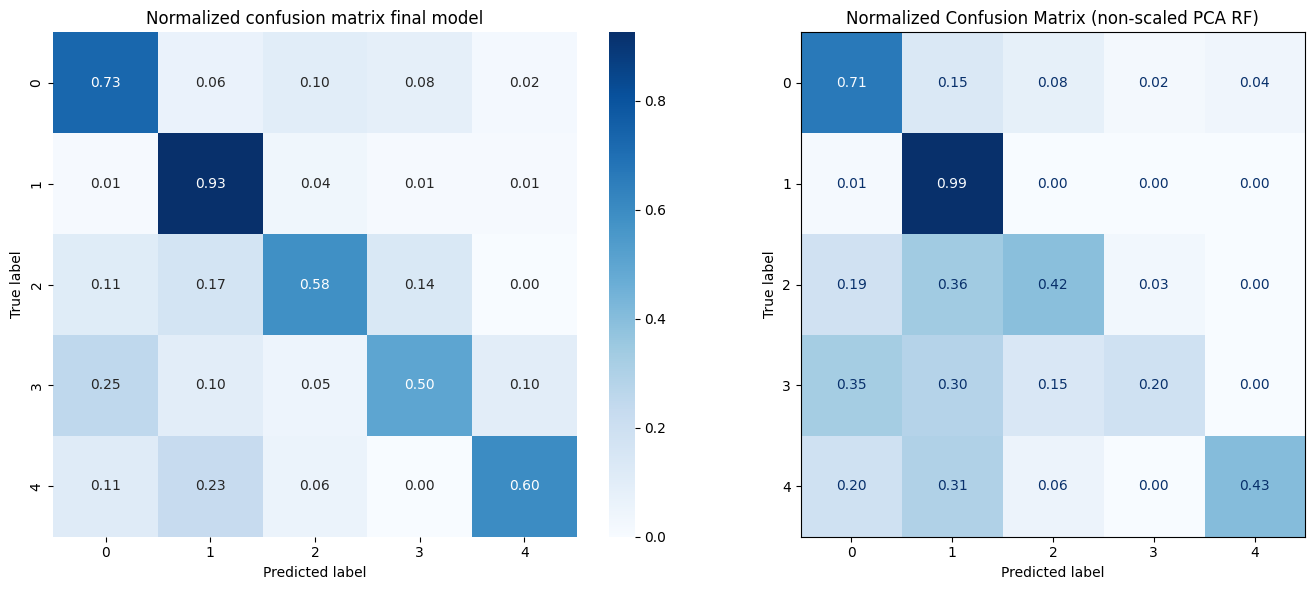

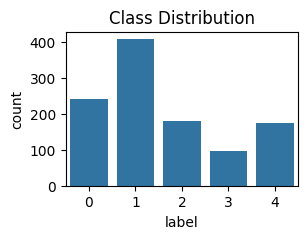

In [32]:
y_pred = final_model.predict(X_test_reduced)
cm_1 = confusion_matrix(y_test, y_pred, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_1, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_,
            ax=axes[0])
axes[0].set_title("Normalized confusion matrix final model")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

disp = ConfusionMatrixDisplay(cm, display_labels=final_model.classes_)
disp.plot(ax=axes[1], cmap="Blues", values_format=".2f", colorbar=False)
axes[1].set_title("Normalized Confusion Matrix (non-scaled PCA RF)")
plt.tight_layout()
plt.show()
plt.figure(figsize=(3, 2))
sns.countplot(x=df.iloc[:, 1])
plt.title("Class Distribution")
plt.show()

We can see a significant improvement considering the labels that contained the least amount of samples (2, 3, 4) with a slight drop regarding samples 0 and 1. We managed to obtain an accuracy score 73.63%, while reducing the imbalance significantly. Of course different classes are still getting different results with the smallest samples one getting the worse, but we can see a huge improvement and that is important. We can see the biggest percentage mistake where the model predicts a true label 3 incorrectly as a label 0 with 25% of such errors for class 3.

### Conclusions

### Final model overview

Our final model used:  
-Non scaled PCA keeping 14 components and 96.57% of explained variance  
-Random Forest classifier  
-SMOTE oversampling method  

Parameters that our model used:   
-max_depth: 50  
-max_features: 'sqrt'  
-min_samples_leaf: 1  
-min_samples_split: 2  
-n_estimators: 574 

Main scores report:  
-Accuracy: 0.7363    
-macro avg F1 score: 0.6793    
-weighted avg F1 score: 0.7309   


### Practical considerations

I could of course tune the model up even more by testing different parameters, trying more advanced methods or searching for correlations between parameter values. However, our model went through a massive improvement not only accuracy wise, but also balance wise so the exploration was concluded with a success.

### Predicting labels on new dataset

In [33]:
test_data = pd.read_csv("mldata_0003247767.TEST_FEATURES.csv")
X_test_raw = test_data.drop(columns=["id"])
X_test_pca = pca.transform(X_test_raw)
y_pred = final_model.predict(X_test_pca)
np.savetxt("final_predictions.txt", y_pred, fmt='%d')